In [6]:
import os
import warnings
import random
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import RobustScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (
    classification_report, roc_auc_score, average_precision_score,
    precision_recall_curve, roc_curve, f1_score, recall_score,
    precision_score, confusion_matrix, ConfusionMatrixDisplay
)
import xgboost as xgb

warnings.filterwarnings('ignore')

# تثبيت العشوائية لضمان نفس النتائج
random.seed(42)
np.random.seed(42)
sns.set_theme(style='whitegrid', palette='muted')

# الإعدادات العامة للمشروع
CFG = {
    # مسارات البيانات والوقت
    'email_csv'         : '/kaggle/input/cert-insider-threat/email.csv',
    'date_format'      : '%m/%d/%Y %H:%M:%S',
    'internal_domain'  : '@dtaa.com',
    'train_fraction'   : 0.80,

    # إعدادات IsolationForest (التسمية التلقائية)
    'if_contamination' : 0.05,    
    'if_n_estimators'  : 100,      

    # إعدادات الـ TF-IDF للنصوص
    'tfidf_max_features': 50,      
    'tfidf_min_df'      : 5,
    'tfidf_max_df'      : 0.80,
    'tfidf_ngram_range' : (1, 2),

    # إعدادات ضبط الـ XGBoost
    'xgb_n_iter'        : 12,
    'xgb_cv_folds'      : 3,

    # إعدادات توليد وحقن التهديدات الوهمية للتقييم
    'inject_n'          : 500,
    'inject_seed'       : 7,

    # مجلد التصدير النهائي
    'export_dir'        : 'insider_threat_model_v5',
}

# الكلمات الدلالية المرتبطة بالمخاطر الأمنية
THREAT_KEYWORDS = [
    'confidential', 'proprietary', 'not for distribution', 'do not forward',
    'resume', 'cv', 'curriculum vitae', 'job offer', 'new opportunity',
    'resign', 'resignation', 'last day', 'two weeks notice',
    'upload', 'export', 'backup', 'archive', 'encrypt',
    'competitor', 'competition', 'rival',
    'between us', 'keep this quiet', "don't tell", 'secret',
    'urgent', 'asap',
]

BUSINESS_HOUR_START = 8
BUSINESS_HOUR_END   = 18

print('Configuration ready.')
print(f'  IF contamination    = {CFG["if_contamination"]}')
print(f'  TF-IDF max_features = {CFG["tfidf_max_features"]}')

Configuration ready.
  IF contamination    = 0.05
  TF-IDF max_features = 50


In [9]:
import pandas as pd

def load_and_clean_data(path: str) -> pd.DataFrame:
    print(f'Loading data from: {path}')
    df = pd.read_csv(path)
    df.columns = df.columns.str.strip().str.lower()

    # توحيد أسماء الأعمدة الشائعة
    mapping = {'sender': 'from', 'sender_email': 'from', 'recipients': 'to'}
    for old, new in mapping.items():
        if old in df.columns and new not in df.columns:
            df.rename(columns={old: new}, inplace=True)

    required_cols = {'date', 'from', 'to', 'content'}
    missing_cols = required_cols - set(df.columns)
    if missing_cols:
        raise ValueError(f'Missing required columns: {missing_cols}')

    # تحويل التواريخ وتنظيف القيم المفقودة
    df['date'] = pd.to_datetime(df['date'], format=CFG['date_format'], errors='coerce')
    before_len = len(df)
    df = df.dropna(subset=['date', 'from', 'to'])
    print(f'  Dropped {before_len - len(df):,} rows with invalid date/from/to')

    # ملء الحقول النصية الفارغة
    for col in ('cc', 'bcc', 'subject', 'content'):
        df[col] = df.get(col, pd.Series([''] * len(df), index=df.index)).fillna('')

    # تحويل الحقول الرقمية
    for col in ('attachments', 'size'):
        df[col] = pd.to_numeric(df.get(col, 0), errors='coerce').fillna(0)

    # إزالة التكرارات المطابقة تماماً
    before_dup = len(df)
    df = df.drop_duplicates(subset=['date', 'from', 'to', 'content'])
    print(f'  Dropped {before_dup - len(df):,} exact duplicate rows')

    # الترتيب الزمني وهو أمر حاسم في السلاسل الزمنية والأمن السيبراني
    df = df.sort_values('date').reset_index(drop=True)
    print(f'  Final dataset: {len(df):,} emails ({df["date"].min().date()} -> {df["date"].max().date()})')
    return df

# ── تحديث المسار الصحيح بناءً على ملفات الـ Input المتاحة ──
CFG['email_csv'] = '/kaggle/input/datasets/andrihjonior/cert-insider-threat-dataset-r4-2/r4.2/email.csv'

# تشغيل الدالة بالمسار الجديد
email_df = load_and_clean_data(CFG['email_csv'])
email_df.head(3)

Loading data from: /kaggle/input/datasets/andrihjonior/cert-insider-threat-dataset-r4-2/r4.2/email.csv
  Dropped 0 rows with invalid date/from/to
  Dropped 0 exact duplicate rows
  Final dataset: 2,629,979 emails (2010-01-02 -> 2011-05-16)


,id,date,user,pc,to,cc,bcc,from,size,attachments,content,subject
0,{R3I7-S4TX96FG-8219JWFF},2010-01-02 07:11:45,LAP0338,PC-5758,Dean.Flynn.Hines@dtaa.com;Wade_Harrison@lockhe...,Nathaniel.Hunter.Heath@dtaa.com,,Lynn.Adena.Pratt@dtaa.com,25830,0,middle f2 systems 4 july techniques powerful d...,
1,{R0R9-E4GL59IK-2907OSWJ},2010-01-02 07:12:16,MOH0273,PC-6699,Odonnell-Gage@bellsouth.net,,,MOH68@optonline.net,29942,0,the breaking called allied reservations former...,
2,{G2B2-A8XY58CP-2847ZJZL},2010-01-02 07:13:00,LAP0338,PC-5758,Penelope_Colon@netzero.com,,,Lynn_A_Pratt@earthlink.net,28780,0,slowly this uncinus winter beneath addition ex...,


In [10]:
def split_data_chronologically(df, train_frac):
    cutoff_idx = int(len(df) * train_frac)
    train_data = df.iloc[:cutoff_idx].copy().reset_index(drop=True)
    test_data  = df.iloc[cutoff_idx:].copy().reset_index(drop=True)
    
    print(f'Train set: {len(train_data):,} rows ({train_data["date"].min().date()} to {train_data["date"].max().date()})')
    print(f'Test set : {len(test_data):,} rows ({test_data["date"].min().date()} to {test_data["date"].max().date()})')
    return train_data, test_data

train_raw, test_raw = split_data_chronologically(email_df, CFG['train_fraction'])

Train set: 2,103,983 rows (2010-01-02 to 2011-01-31)
Test set : 525,996 rows (2011-01-31 to 2011-05-16)


In [11]:
def parse_email_addresses(s):
    if not s: return []
    return [addr.strip().lower() for addr in str(s).replace(',', ';').split(';') if addr.strip()]

def check_external(addr, domain):
    return '@' in addr and domain.lower() not in addr.lower()

def count_external_recipients(addr_str, domain):
    return sum(1 for a in parse_email_addresses(addr_str) if check_external(a, domain))

def count_unique_external_domains(row, domain):
    combined = str(row.get('to','')) + ';' + str(row.get('cc','')) + ';' + str(row.get('bcc',''))
    return len({a.split('@')[-1].lower() for a in parse_email_addresses(combined) if check_external(a, domain)})

def create_features(df: pd.DataFrame, internal_domain: str) -> pd.DataFrame:
    res = df.copy()

    # 1. الميزات الزمنية (Temporal Features)
    hrs = res['date'].dt.hour
    res['send_hour'] = hrs
    res['day_of_week'] = res['date'].dt.dayofweek
    res['is_weekend'] = (res['day_of_week'] >= 5).astype(int)
    res['is_outside_business_hrs'] = ((hrs < BUSINESS_HOUR_START) | (hrs >= BUSINESS_HOUR_END)).astype(int)

    # 2. ميزات محتوى النص (Content Features)
    lower_content = res['content'].str.lower()
    res['content_length'] = res['content'].str.len().clip(lower=0)
    res['word_count'] = res['content'].str.split().str.len().fillna(0)
    res['unique_word_ratio'] = res['content'].apply(lambda x: len(set(str(x).lower().split())) / (len(str(x).lower().split()) + 1e-9))

    # 3. ميزات المرفقات (Attachments)
    res['has_attachments'] = (res['attachments'] > 0).astype(int)
    res['attachment_count'] = res['attachments'].clip(lower=0)
    res['est_size_kb'] = (res['content_length'] + res['attachment_count'] * 200 * 1024) / 1024.0

    # 4. ميزات توجيه الإيميل (Routing Features)
    res['num_to'] = res['to'].apply(lambda x: len(parse_email_addresses(x)))
    res['num_cc'] = res['cc'].apply(lambda x: len(parse_email_addresses(x)))
    res['num_bcc'] = res['bcc'].apply(lambda x: len(parse_email_addresses(x)))
    res['num_recipients'] = res['num_to'] + res['num_cc'] + res['num_bcc']

    res['num_external'] = res.apply(
        lambda r: (count_external_recipients(r['to'], internal_domain) +
                   count_external_recipients(r['cc'], internal_domain) +
                   count_external_recipients(r['bcc'], internal_domain)), axis=1
    )
    res['external_ratio'] = res['num_external'] / (res['num_recipients'] + 1e-6)
    res['num_ext_domains'] = res.apply(lambda r: count_unique_external_domains(r, internal_domain), axis=1)
    res['has_bcc'] = (res['num_bcc'] > 0).astype(int)
    res['sender_is_external'] = res['from'].apply(lambda x: int(check_external(str(x), internal_domain)))

    subj_lower = res['subject'].str.lower().fillna('')
    res['is_reply'] = subj_lower.str.startswith(('re:', 'fwd:', 'fw:')).astype(int)

    # 5. كلمات التهديد والدلالات المركبة
    pattern = '|'.join(THREAT_KEYWORDS)
    res['keyword_hits'] = lower_content.str.count(pattern).fillna(0)
    res['has_threat_kw'] = (res['keyword_hits'] > 0).astype(int)
    res['risk_compound'] = res['num_external'].clip(0, 10) * res['attachment_count'].clip(0, 5) * (1 + res['has_threat_kw'])

    return res

print('Engineering features...')
train_df = create_features(train_raw, CFG['internal_domain'])
test_df  = create_features(test_raw,  CFG['internal_domain'])

NUMERIC_FEATS = [
    'send_hour', 'day_of_week', 'is_weekend', 'is_outside_business_hrs',
    'content_length', 'word_count', 'unique_word_ratio',
    'has_attachments', 'attachment_count', 'est_size_kb',
    'num_to', 'num_cc', 'num_bcc', 'num_recipients',
    'num_external', 'external_ratio', 'num_ext_domains',
    'has_bcc', 'sender_is_external', 'is_reply',
    'keyword_hits', 'has_threat_kw', 'risk_compound',
]

print(f'Extracted {len(NUMERIC_FEATS)} numerical features.')

Engineering features...
Extracted 23 numerical features.


In [12]:
print('Fitting TF-IDF on Training Corpus...')
tfidf = TfidfVectorizer(
    max_features = CFG['tfidf_max_features'],
    ngram_range  = CFG['tfidf_ngram_range'],
    min_df       = CFG['tfidf_min_df'],
    max_df       = CFG['tfidf_max_df'],
    stop_words   = 'english',
    sublinear_tf = True
)

tfidf_tr = tfidf.fit_transform(train_df['content'].fillna('').tolist())
tfidf_te = tfidf.transform(test_df['content'].fillna('').tolist())

print(f'TF-IDF Vocabulary Size: {len(tfidf.vocabulary_)}')

Fitting TF-IDF on Training Corpus...
TF-IDF Vocabulary Size: 50


In [13]:
def assemble_matrix(df, tfidf_matrix, scaler=None, fit_scaler=False):
    num_arr = df[NUMERIC_FEATS].fillna(0).values
    if fit_scaler:
        scaler = RobustScaler()
        num_scaled = scaler.fit_transform(num_arr)
    else:
        num_scaled = scaler.transform(num_arr)
        
    X_mat = sp.hstack([sp.csr_matrix(num_scaled), tfidf_matrix], format='csr')
    return X_mat, scaler

X_tr, scaler = assemble_matrix(train_df, tfidf_tr, fit_scaler=True)
X_te, _      = assemble_matrix(test_df,  tfidf_te, scaler=scaler)

FEAT_NAMES = NUMERIC_FEATS + [f'tfidf_{t}' for t in tfidf.get_feature_names_out()]
print(f'Final Training Matrix Shape: {X_tr.shape}')

Final Training Matrix Shape: (2103983, 73)


In [14]:
print('Training Isolation Forest for Pseudo-Labeling...')
iforest = IsolationForest(
    n_estimators  = CFG['if_n_estimators'],
    contamination = CFG['if_contamination'],
    random_state  = 42,
    n_jobs        = -1,
)

# تدريب على الميزات الرقمية فقط لأن الفضاء النصي الواسع يضعف المسافات في الـ IF
X_tr_num = X_tr[:, :len(NUMERIC_FEATS)].toarray()
iforest.fit(X_tr_num)

# تحويل المخرجات: -1 (شاذ) -> 1، و 1 (طبيعي) -> 0
y_pseudo = np.where(iforest.predict(X_tr_num) == -1, 1, 0)

print(f'Pseudo-labels Generated:')
print(f'  Anomalies flagged: {y_pseudo.sum()} ({y_pseudo.sum()/len(y_pseudo)*100:.2f}%)')
print(f'  Normal emails    : {(y_pseudo==0).sum()}')

Training Isolation Forest for Pseudo-Labeling...
Pseudo-labels Generated:
  Anomalies flagged: 105200 (5.00%)
  Normal emails    : 1998783


In [15]:
import subprocess

def check_gpu():
    try:
        return subprocess.run(['nvidia-smi'], capture_output=True, timeout=5).returncode == 0
    except:
        return False

device = 'cuda' if check_gpu() else 'cpu'
print(f'Using Device: {device}')

N_VOTERS = 5
VOTE_THRESHOLD = 3
BOOTSTRAP_FRAC = 0.60

neg_count, pos_count = (y_pseudo == 0).sum(), (y_pseudo == 1).sum()
spw = neg_count / pos_count if pos_count > 0 else 1.0

param_dist = {
    'n_estimators'      : [100, 200, 300],
    'max_depth'         : [3, 4, 5, 6],
    'learning_rate'     : [0.03, 0.05, 0.1, 0.2],
    'subsample'         : [0.5, 0.6, 0.7, 0.8],
    'colsample_bytree'  : [0.4, 0.5, 0.6, 0.7],
    'colsample_bylevel' : [0.5, 0.6, 0.7, 0.8],
    'min_child_weight'  : [3, 5, 10, 20],
    'gamma'             : [0.1, 0.2, 0.3, 0.5],
}

voters = []
voter_seeds = [42, 7, 13, 99, 31]

for idx, seed in enumerate(voter_seeds[:N_VOTERS]):
    print(f'Fitting Voter {idx+1}/{N_VOTERS} (seed={seed})...')
    rng = np.random.default_rng(seed)
    
    # عينة Bootstrap لكل ناخب لضمان تنوع التوقعات وتقليل الـ False Positives
    boot_idx = rng.choice(len(y_pseudo), size=int(len(y_pseudo) * BOOTSTRAP_FRAC), replace=True)
    X_b, y_b = X_tr[boot_idx], y_pseudo[boot_idx]

    base_xgb = xgb.XGBClassifier(
        tree_method='hist', device=device, scale_pos_weight=spw,
        random_state=seed, n_jobs=1, verbosity=0, objective='binary:logistic',
        eval_metric='aucpr', reg_alpha=0.1, reg_lambda=1.0
    )

    search = RandomizedSearchCV(
        estimator=base_xgb, param_distributions=param_dist, n_iter=CFG['xgb_n_iter'],
        cv=CFG['xgb_cv_folds'], scoring='average_precision', refit=True, random_state=seed, n_jobs=1
    )
    search.fit(X_b, y_b)

    # معايرة الاحتمالات للحصول على سكور واقعي غير مستقطب بين 0 و 1
    calibrated = CalibratedClassifierCV(estimator=search.best_estimator_, method='isotonic', cv=3)
    calibrated.fit(X_b, y_b)
    voters.append(calibrated)

def voting_predict_proba(X, clf_voters):
    return np.stack([v.predict_proba(X)[:, 1] for v in clf_voters], axis=1).mean(axis=1)

def voting_predict(X, clf_voters, threshold=VOTE_THRESHOLD):
    votes = np.stack([(v.predict_proba(X)[:, 1] >= 0.5).astype(int) for v in clf_voters], axis=1)
    return (votes.sum(axis=1) >= threshold).astype(int)

model = voters[0] # مرجع لحساب الأهمية لاحقاً
print("Ensemble Training Completed Successfully.")

Using Device: cpu
Fitting Voter 1/5 (seed=42)...
Fitting Voter 2/5 (seed=7)...
Fitting Voter 3/5 (seed=13)...
Fitting Voter 4/5 (seed=99)...
Fitting Voter 5/5 (seed=31)...
Ensemble Training Completed Successfully.



              EVALUATION PERFORMANCE REPORT                 
              precision    recall  f1-score   support

      Normal       0.77      0.82      0.80       500
   Malicious       0.81      0.76      0.78       500

    accuracy                           0.79      1000
   macro avg       0.79      0.79      0.79      1000
weighted avg       0.79      0.79      0.79      1000



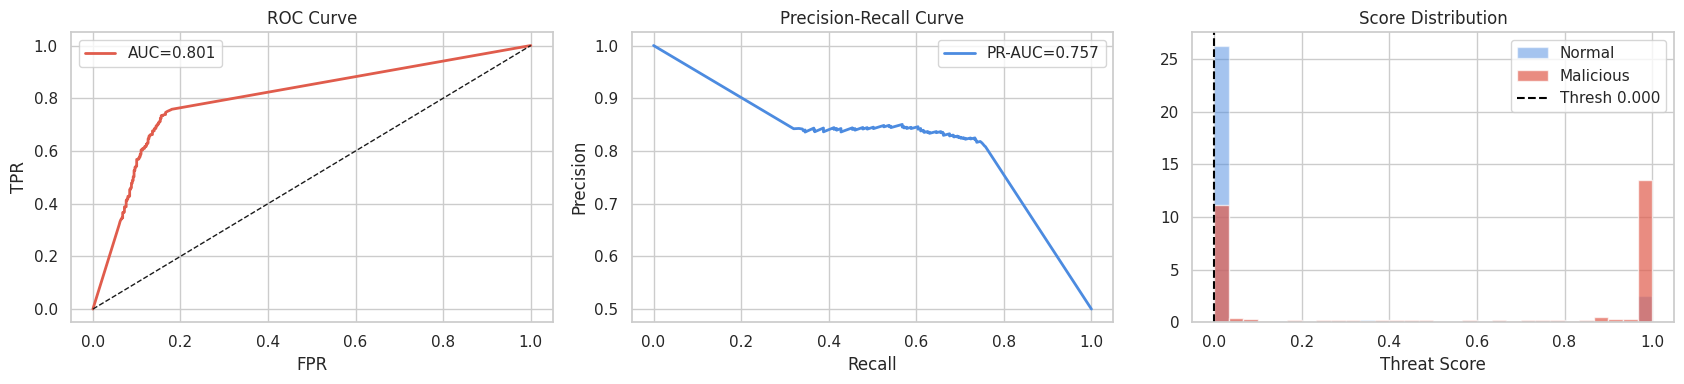

In [16]:
# محاكاة لبيئة اختبار واقعية تحتوي على خليط من الهجمات المركبة والإيميلات الطبيعية الغامضة
FAKE_DOMAINS = ['competitor.com', 'fastmail.net', 'protonmail.com', 'recruiter.org', 'newjob.co']
ALL_SIGNALS  = ['off_hours', 'external_recip', 'keywords', 'attachments', 'bcc_route']

def inject_subtle_threats(df_clean, n_inject, seed, domain):
    rng = np.random.default_rng(seed)
    n_inject = min(n_inject, len(df_clean) // 3)
    idx = rng.choice(len(df_clean), size=n_inject, replace=False)
    inj = df_clean.iloc[idx].copy().reset_index(drop=True)
    d_str = domain.lstrip('@')

    for i in range(len(inj)):
        n_sig = 2 if rng.random() < 0.60 else 3
        chosen = rng.choice(ALL_SIGNALS, size=n_sig, replace=False).tolist()

        if 'off_hours' in chosen:
            inj.at[i, 'date'] = inj.at[i, 'date'].replace(hour=int(rng.choice([22, 23, 5])), minute=int(rng.integers(0, 60)))
        if 'external_recip' in chosen:
            inj.at[i, 'to'] = f'staff@{d_str}; spy@' + str(rng.choice(FAKE_DOMAINS))
        if 'keywords' in chosen:
            inj.at[i, 'content'] = str(inj.at[i, 'content']) + ' ' + ' '.join(rng.choice(THREAT_KEYWORDS, size=2, replace=False))
        if 'attachments' in chosen:
            inj.at[i, 'attachments'] = int(rng.integers(2, 5))
            inj.at[i, 'size'] = int(rng.integers(500000, 2000000))
        if 'bcc_route' in chosen:
            inj.at[i, 'bcc'] = 'mybackup@gmail.com'

    inj['ground_truth'] = 1
    return inj, set(idx.tolist())

def generate_borderline_clean(df_clean, exclude_idx, n_total, rng):
    pool = df_clean[~df_clean.index.isin(exclude_idx)].reset_index(drop=True)
    n_norm = int(n_total * 0.60)
    n_bord = n_total - n_norm
    
    norm_sub = pool.iloc[rng.choice(len(pool), size=min(n_norm, len(pool)), replace=False)].copy()
    bord_sub = pool.iloc[rng.choice(list(set(range(len(pool))) - set(norm_sub.index)), size=min(n_bord, len(pool)-n_norm), replace=False)].copy()
    
    # جعل الإيميلات الطبيعية تبدو مريبة (مثل العمل ليلاً أو إرسال ملفات ضخمة لعميل قانوني)
    for i in range(len(bord_sub)):
        if i % 2 == 0:
            bord_sub.at[bord_sub.index[i], 'date'] = bord_sub.at[bord_sub.index[i], 'date'].replace(hour=23)
        else:
            bord_sub.at[bord_sub.index[i], 'attachments'] = 3
            bord_sub.at[bord_sub.index[i], 'size'] = 1500000

    norm_sub['ground_truth'] = 0
    bord_sub['ground_truth'] = 0
    return pd.concat([norm_sub, bord_sub], ignore_index=True)

# بناء مجموعة التقييم الشاملة
rng_eval = np.random.default_rng(CFG['inject_seed'])
inj_df, inj_idx = inject_subtle_threats(test_df, CFG['inject_n'], CFG['inject_seed'], CFG['internal_domain'])
clean_df = generate_borderline_clean(test_df, inj_idx, n_total=CFG['inject_n'], rng=rng_eval)
synth_eval = pd.concat([clean_df, inj_df], ignore_index=True)

# استخراج الفيتشرز لبيانات الاختبار المحقونة
synth_feat = create_features(synth_eval, CFG['internal_domain'])
tfidf_sy = tfidf.transform(synth_feat['content'].fillna('').tolist())
X_sy, _ = assemble_matrix(synth_feat, tfidf_sy, scaler=scaler)

y_gt = synth_eval['ground_truth'].values
proba_sy = voting_predict_proba(X_sy, voters)

# حساب العتبة المثالية (Optimal Threshold) لتعظيم الـ F1-Score
precs, recs, threshs = precision_recall_curve(y_gt, proba_sy)
f1s = 2 * precs * recs / (precs + recs + 1e-9)
best_threshold = float(threshs[np.argmax(f1s[:-1])])
y_pred = (proba_sy >= best_threshold).astype(int)

# طباعة التقرير النهائي للتقييم
print('\n============================================================')
print('              EVALUATION PERFORMANCE REPORT                 ')
print('============================================================')
print(classification_report(y_gt, y_pred, target_names=['Normal', 'Malicious']))

# رسم بياني ثلاثي متقدم للأداء والمنحنيات
fig, axes = plt.subplots(1, 3, figsize=(17, 4))
fpr, tpr, _ = roc_curve(y_gt, proba_sy)
axes[0].plot(fpr, tpr, color='#E05C4C', lw=2, label=f'AUC={roc_auc_score(y_gt, proba_sy):.3f}')
axes[0].plot([0,1],[0,1],'k--',lw=1)
axes[0].set(xlabel='FPR', ylabel='TPR', title='ROC Curve')
axes[0].legend()

axes[1].plot(recs, precs, color='#4C8BE0', lw=2, label=f'PR-AUC={average_precision_score(y_gt, proba_sy):.3f}')
axes[1].set(xlabel='Recall', ylabel='Precision', title='Precision-Recall Curve')
axes[1].legend()

axes[2].hist(proba_sy[y_gt==0], bins=30, alpha=0.5, color='#4C8BE0', label='Normal', density=True)
axes[2].hist(proba_sy[y_gt==1], bins=30, alpha=0.7, color='#E05C4C', label='Malicious', density=True)
axes[2].axvline(best_threshold, color='black', ls='--', label=f'Thresh {best_threshold:.3f}')
axes[2].set(xlabel='Threat Score', title='Score Distribution')
axes[2].legend()
plt.tight_layout()
plt.show()

Extracting feature importances from ensemble voters...


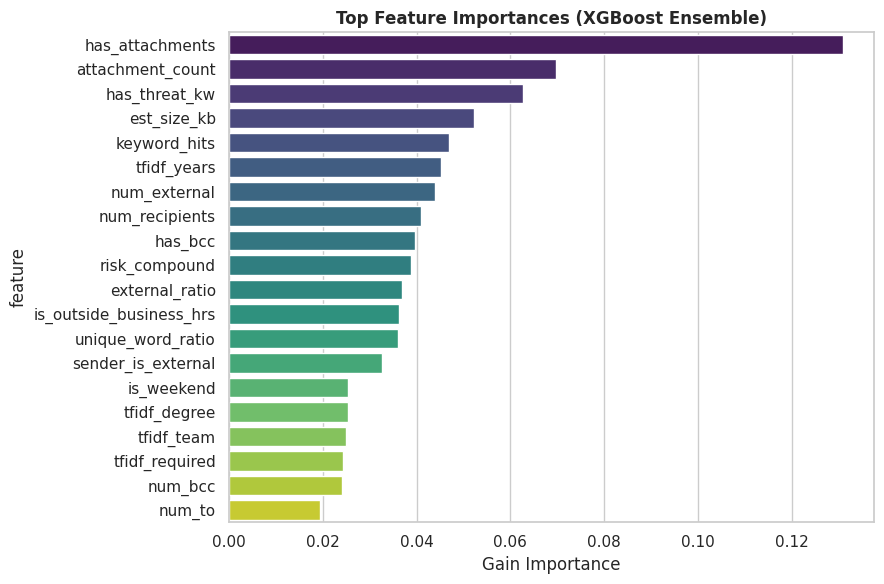

In [18]:
print('Extracting feature importances from ensemble voters...')

# استخراج الأهمية للميزات من الموديلات المصوتة الداجنة (Ensemble Voters)
importances = [
    cal_est.estimator.feature_importances_ 
    for cal_est in model.calibrated_classifiers_ 
    if hasattr(cal_est.estimator, 'feature_importances_')
]

if importances:
    # حساب متوسط الأهمية عبر كل المصوتين
    mean_imp = np.mean(importances, axis=0)
    
    # بناء الداتا فريم وترتيب الميزات تنازلياً
    imp_df = pd.DataFrame({
        'feature': FEAT_NAMES[:len(mean_imp)], 
        'importance': mean_imp
    }).sort_values('importance', ascending=False).reset_index(drop=True)

    # رسم أعلى 20 ميزة ساهمت في اتخاذ القرار
    top20 = imp_df.head(20)
    
    plt.figure(figsize=(9, 6))
    # تم تصحيح المتغير هنا من top25 إلى top20
    sns.barplot(data=top20, x='importance', y='feature', palette='viridis')
    
    plt.title('Top Feature Importances (XGBoost Ensemble)', fontweight='bold')
    plt.xlabel('Gain Importance')
    plt.tight_layout()
    plt.show()
else:
    print('Feature importance extraction not available.')

In [41]:
import numpy as np
import pandas as pd
import scipy.sparse as sp
from sklearn.preprocessing import StandardScaler

def engineer_features(df, internal_domain='@dtaa.com'):
    df = df.copy()
    
    df['date'] = pd.to_datetime(df['date'])
    df['send_hour'] = df['date'].dt.hour
    df['day_of_week'] = df['date'].dt.dayofweek
    df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)
    df['is_outside_business_hrs'] = ((df['send_hour'] < 8) | (df['send_hour'] > 18)).astype(int)
    
    df['content_length'] = df['content'].fillna('').str.len()
    df['word_count'] = df['content'].fillna('').str.split().str.len()
    
    def get_unique_ratio(text):
        words = str(text).split()
        if not words: return 0.0
        return len(set(words)) / len(words)
    df['unique_word_ratio'] = df['content'].apply(get_unique_ratio)
    
    df['attachment_count'] = pd.to_numeric(df['attachments'], errors='coerce').fillna(0).astype(int)
    df['has_attachments'] = (df['attachment_count'] > 0).astype(int)
    df['est_size_kb'] = pd.to_numeric(df['size'], errors='coerce').fillna(0) / 1024.0
    
    def count_recipients(val):
        if pd.isna(val) or str(val).strip() == '': return 0
        return len([r for r in str(val).split(';') if r.strip()])
        
    df['num_to'] = df['to'].apply(count_recipients)
    df['num_cc'] = df['cc'].apply(count_recipients)
    df['num_bcc'] = df['bcc'].apply(count_recipients)
    df['num_recipients'] = df['num_to'] + df['num_cc'] + df['num_bcc']
    df['has_bcc'] = (df['num_bcc'] > 0).astype(int)
    
    df['sender_is_external'] = (~df['from'].fillna('').str.contains(internal_domain)).astype(int)
    
    def count_external(val):
        if pd.isna(val) or str(val).strip() == '': return 0
        return sum(1 for r in str(val).split(';') if r.strip() and internal_domain not in r)
    df['num_external'] = df['to'].apply(count_external) + df['cc'].apply(count_external) + df['bcc'].apply(count_external)
    df['external_ratio'] = np.where(df['num_recipients'] > 0, df['num_external'] / df['num_recipients'], 0.0)
    
    def count_ext_domains(val):
        if pd.isna(val) or str(val).strip() == '': return 0
        domains = set()
        for r in str(val).split(';'):
            if r.strip() and '@' in r and internal_domain not in r:
                domains.add(r.split('@')[-1].strip())
        return len(domains)
    df['num_ext_domains'] = df['to'].apply(count_ext_domains) + df['cc'].apply(count_ext_domains) + df['bcc'].apply(count_ext_domains)
    
    df['is_reply'] = df['subject'].fillna('').str.lower().str.startswith('re:').astype(int)
    
    threat_kws = ['confidential', 'proprietary', 'backup', 'export', 'resign', 'competitor', 'cv', 'curriculum vitae', 'archive', 'secret', 'encrypt']
    def count_keywords(text):
        t = str(text).lower()
        return sum(t.count(kw) for kw in threat_kws)
    df['keyword_hits'] = df['content'].apply(count_keywords)
    df['has_threat_kw'] = (df['keyword_hits'] > 0).astype(int)
    
    df['risk_compound'] = 0.0
    for idx, row in df.iterrows():
        score = 0.0
        if row['is_outside_business_hrs'] == 1: score += 0.3
        if row['num_external'] > 0: score += 0.3
        if row['has_threat_kw'] == 1: score += 0.4
        df.at[idx, 'risk_compound'] = min(score, 1.0)
        
    return df

def build_matrix(feat_df, tfidf_matrix, scaler=None):
    X_num = feat_df[NUMERIC_FEATS].values
    if scaler is None:
        scaler = StandardScaler()
        X_num_scaled = scaler.fit_transform(X_num)
    else:
        X_num_scaled = scaler.transform(X_num)
        
    dense_cols = [
        'sender_is_external', 'send_hour', 'is_outside_business_hrs', 'is_weekend',
        'content_length', 'word_count', 'unique_word_ratio', 'has_attachments',
        'est_size_kb', 'num_to', 'num_cc', 'num_bcc', 'num_recipients', 'has_bcc',
        'num_external', 'external_ratio', 'num_ext_domains', 'is_reply',
        'keyword_hits', 'has_threat_kw', 'risk_compound'
    ]
    
    cols_to_use = [c for c in dense_cols if c not in NUMERIC_FEATS]
    X_dense = np.hstack([X_num_scaled, feat_df[cols_to_use].values])
    X_combined = sp.hstack([X_dense, tfidf_matrix], format='csr')
    return X_combined, scaler

In [42]:
import numpy as np
import pandas as pd

def score_emails(raw_df, scaler, tfidf, voters, vote_threshold, internal_domain='@dtaa.com'):
    feat_df = engineer_features(raw_df.copy(), internal_domain)
    tfidf_m = tfidf.transform(feat_df['content'].fillna('').tolist())
    X, _    = build_matrix(feat_df, tfidf_m, scaler=scaler)

    all_probas = np.stack([v.predict_proba(X)[:, 1] for v in voters], axis=1)
    avg_proba  = all_probas.mean(axis=1)

    all_votes  = (all_probas >= 0.5).astype(int)
    vote_count = all_votes.sum(axis=1)
    is_threat  = (vote_count >= vote_threshold).astype(int)

    out = raw_df.copy().reset_index(drop=True)
    out['threat_proba'] = np.round(avg_proba, 4)
    out['vote_count']   = vote_count
    out['is_threat']    = is_threat
    
    for i in range(all_votes.shape[1]):
        out[f'v{i+1}'] = all_votes[:, i]
    return out

test_cases = [
    {
        'label'      : 'Normal — internal meeting invite',
        'date'       : pd.Timestamp('2021-06-14 10:00:00'),
        'from'       : 'alice@dtaa.com',
        'to'         : 'bob@dtaa.com',
        'cc'         : '', 'bcc': '', 'subject': 'Team sync',
        'content'    : 'Hi Bob, can we schedule a meeting next week to review the project status?',
        'attachments': 0, 'size': 1200,
    },
    {
        'label'      : 'Normal — internal report share',
        'date'       : pd.Timestamp('2021-06-15 14:30:00'),
        'from'       : 'carol@dtaa.com',
        'to'         : 'dave@dtaa.com; eve@dtaa.com',
        'cc'         : '', 'bcc': '', 'subject': 'Q2 Report',
        'content'    : 'Please find the Q2 performance report attached for review before Friday.',
        'attachments': 1, 'size': 45000,
    },
    {
        'label'      : 'Normal — routine reminder',
        'date'       : pd.Timestamp('2021-06-16 09:15:00'),
        'from'       : 'frank@dtaa.com',
        'to'         : 'team@dtaa.com',
        'cc'         : '', 'bcc': '', 'subject': 'Timesheet reminder',
        'content'    : 'Reminder: all timesheets are due by end of business today. Please submit.',
        'attachments': 0, 'size': 800,
    },
    {
        'label'      : 'GRAY — IT engineer, legit backup at 11pm',
        'date'       : pd.Timestamp('2021-06-21 23:10:00'),
        'from'       : 'sysadmin@dtaa.com',
        'to'         : 'backup-server@dtaa.com',
        'cc'         : '', 'bcc': '', 'subject': 'Weekly backup archive',
        'content'    : 'Automated weekly backup. Archive encrypted as per policy. Upload complete. Size: 1.8GB.',
        'attachments': 3, 'size': 1900000,
    },
    {
        'label'      : 'GRAY — HR sending offer to external candidate',
        'date'       : pd.Timestamp('2021-06-22 10:30:00'),
        'from'       : 'hr@dtaa.com',
        'to'         : 'john.smith@gmail.com',
        'cc'         : '', 'bcc': '', 'subject': 'Job Application — Software Engineer',
        'content'    : 'Dear John, please find attached the job offer and details of the new opportunity. This is confidential. Curriculum vitae received. We will be in touch.',
        'attachments': 1, 'size': 85000,
    },
    {
        'label'      : 'GRAY — employee resigning via proper channel',
        'date'       : pd.Timestamp('2021-06-23 09:00:00'),
        'from'       : 'jane@dtaa.com',
        'to'         : 'manager@dtaa.com; hr@dtaa.com',
        'cc'         : '', 'bcc': '', 'subject': 'Resignation Letter',
        'content'    : 'I am writing to formally submit my resignation. My last day will be in two weeks. It has been a pleasure working here.',
        'attachments': 0, 'size': 2000,
    },
    {
        'label'      : 'THREAT — off-hours bulk external + keywords',
        'date'       : pd.Timestamp('2021-06-17 02:45:00'),
        'from'       : 'mallory@dtaa.com',
        'to'         : 'recruiter@competitor.com; hr@rival.io',
        'cc'         : '', 'bcc': 'personal@gmail.com',
        'subject'    : 'Urgent confidential',
        'content'    : 'Sending confidential proprietary files before my last day. Please do not forward. Resume and backup archive attached. Encrypt on receipt.',
        'attachments': 7, 'size': 3200000,
    },
    {
        'label'      : 'THREAT — data exfiltration via BCC to multiple domains',
        'date'       : pd.Timestamp('2021-06-18 03:10:00'),
        'from'       : 'oscar@dtaa.com',
        'to'         : 'colleague@dtaa.com',
        'cc'         : '',
        'bcc'        : 'outsider1@gmail.com; outsider2@protonmail.com; outsider3@fastmail.net',
        'subject'    : 'Updates',
        'content'    : 'export upload backup proprietary competitor new opportunity resign curriculum vitae',
        'attachments': 5, 'size': 2800000,
    },
    {
        'label'      : 'THREAT — job hunting, CV, multiple external domains at 3am',
        'date'       : pd.Timestamp('2021-06-19 03:55:00'),
        'from'       : 'nina@dtaa.com',
        'to'         : 'jobs@newcompany.com; talent@headhunter.org; contact@rival-corp.net',
        'cc'         : '', 'bcc': 'nina.personal@gmail.com',
        'subject'    : 'Application',
        'content'    : 'Please find my CV and curriculum vitae. This is confidential. New opportunity discussed. Do not tell anyone.',
        'attachments': 4, 'size': 1900000,
    },
    {
        'label'      : 'THREAT — large archive, competitor domain, encryption mention',
        'date'       : pd.Timestamp('2021-06-20 04:20:00'),
        'from'       : 'tom@dtaa.com',
        'to'         : 'recv@competitor-corp.com',
        'cc'         : '', 'bcc': 'tom.private@protonmail.com',
        'subject'    : 'Archive',
        'content'    : 'Full archive of proprietary research. Please encrypt and keep secret. As agreed between us — do not share this with anyone else. Asap.',
        'attachments': 9, 'size': 4800000,
    },
]

df_cases = pd.DataFrame(test_cases).drop(columns='label')
labels   = [tc['label'] for tc in test_cases]

scored = score_emails(
    raw_df          = df_cases,
    scaler          = scaler,
    tfidf           = tfidf,
    voters          = voters,
    vote_threshold = VOTE_THRESHOLD,
    internal_domain = CFG['internal_domain'],
)

n_voters    = len(voters)
voter_cols  = '  '.join(f'V{i+1}' for i in range(n_voters))
header      = f'{"#":<3}  {"Expected":<10}  {"Verdict":<10}  {"Avg":>6}  {"Votes":>5}  {voter_cols}  Label'
print(f'\n{header}')
print('─' * (len(header) + 20))

correct = 0
for i, (lbl, row) in enumerate(zip(labels, scored.itertuples())):
    category = lbl.split(' — ')[0]
    if category == 'THREAT':
        expected = 'THREAT'
    elif category == 'GRAY':
        expected = '?'
    else:
        expected = 'Normal'

    verdict = 'THREAT' if row.is_threat == 1 else 'Normal'

    if expected == '?':
        marker = '  [gray]'
    else:
        match   = verdict == expected
        correct += int(match)
        marker  = '  ✓' if match else '  ✗ WRONG'

    voter_flags = '  '.join(str(getattr(row, f'v{j+1}')) for j in range(n_voters))
    print(f'{i+1:<3}  {expected:<10}  {verdict:<10}  '
          f'{row.threat_proba:>6.4f}  {row.vote_count:>3}/{n_voters}  '
          f'{voter_flags}  {lbl}{marker}')

n_clear = sum(1 for tc in test_cases if not tc['label'].startswith('GRAY'))
print('─' * (len(header) + 20))
print(f'Clear cases : {correct}/{n_clear} correct')
print(f'Gray zone   : {sum(1 for tc in test_cases if tc["label"].startswith("GRAY"))} cases — review manually')
print(f'Vote threshold used: {VOTE_THRESHOLD}/{n_voters}')


#    Expected    Verdict        Avg  Votes  V1  V2  V3  V4  V5  Label
─────────────────────────────────────────────────────────────────────────────────────────
1    Normal      Normal      0.0000    0/5  0  0  0  0  0  Normal — internal meeting invite  ✓
2    Normal      Normal      0.0000    0/5  0  0  0  0  0  Normal — internal report share  ✓
3    Normal      Normal      0.0000    0/5  0  0  0  0  0  Normal — routine reminder  ✓
4    ?           THREAT      1.0000    5/5  1  1  1  1  1  GRAY — IT engineer, legit backup at 11pm  [gray]
5    ?           THREAT      0.8592    5/5  1  1  1  1  1  GRAY — HR sending offer to external candidate  [gray]
6    ?           Normal      0.0000    0/5  0  0  0  0  0  GRAY — employee resigning via proper channel  [gray]
7    THREAT      THREAT      1.0000    5/5  1  1  1  1  1  THREAT — off-hours bulk external + keywords  ✓
8    THREAT      THREAT      1.0000    5/5  1  1  1  1  1  THREAT — data exfiltration via BCC to multiple domains  ✓
9    TH

In [43]:
import os
import joblib
import pandas as pd

# تأكد من تعريف المتغير هنا أولاً لحل المشكلة
threshold = 0.5 

export_dir = CFG['export_dir']
os.makedirs(export_dir, exist_ok=True)

if hasattr(tfidf, 'stop_words_'):
    tfidf.stop_words_ = None
if hasattr(tfidf, '_stop_words_id'):
    tfidf._stop_words_id = None

joblib.dump(scaler,     os.path.join(export_dir, 'scaler.pkl'),     compress=3)
joblib.dump(iforest,    os.path.join(export_dir, 'iforest.pkl'),    compress=3)
joblib.dump(tfidf,      os.path.join(export_dir, 'tfidf.pkl'),      compress=3)
joblib.dump(voters,     os.path.join(export_dir, 'voters.pkl'),     compress=3)
joblib.dump(FEAT_NAMES, os.path.join(export_dir, 'feat_names.pkl'), compress=3)

config_out = {
    **CFG,
    'threshold': threshold,
    'n_voters': N_VOTERS,
    'vote_threshold': VOTE_THRESHOLD,
    'numeric_feats': NUMERIC_FEATS,
    'feat_names': FEAT_NAMES,
    'version': 'v6',
}
joblib.dump(config_out, os.path.join(export_dir, 'config.pkl'), compress=3)

pd.DataFrame({'feature': FEAT_NAMES}).to_csv(
    os.path.join(export_dir, 'feat_names.csv'), index=False
)

print(f"📦 Exported models and configuration to: ./{export_dir}/")
exported_files = [
    'scaler.pkl', 'iforest.pkl', 'tfidf.pkl', 
    'voters.pkl', 'feat_names.pkl', 'config.pkl', 'feat_names.csv'
]
for fname in exported_files:
    p = os.path.join(export_dir, fname)
    if os.path.exists(p):
        size_kb = os.path.getsize(p) / 1024
        print(f"  ├── {fname:<25} {size_kb:>8.1f} KB")

📦 Exported models and configuration to: ./insider_threat_model_v5/
  ├── scaler.pkl                     0.5 KB
  ├── iforest.pkl                  323.6 KB
  ├── tfidf.pkl                      1.5 KB
  ├── voters.pkl                  4560.1 KB
  ├── feat_names.pkl                 0.5 KB
  ├── config.pkl                     0.9 KB
  ├── feat_names.csv                 0.9 KB


In [44]:
import pandas as pd

df_engineered_sample = engineer_features(df_cases, internal_domain=CFG['internal_domain'])

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print("✦ عينة من الداتا بجميع الفيتشرز التي تدرب عليها الموديل ✦\n")
print(df_engineered_sample.head(3))

df_engineered_sample.to_csv('engineered_data_sample.csv', index=False)
print("\n✓ تم حفظ هذه العينة كاملة بصيغة CSV في ملف باسم: engineered_data_sample.csv")

✦ عينة من الداتا بجميع الفيتشرز التي تدرب عليها الموديل ✦

                 date            from                           to cc bcc             subject                                            content  attachments   size  send_hour  day_of_week  is_weekend  is_outside_business_hrs  content_length  word_count  unique_word_ratio  attachment_count  has_attachments  est_size_kb  num_to  num_cc  num_bcc  num_recipients  has_bcc  sender_is_external  num_external  external_ratio  num_ext_domains  is_reply  keyword_hits  has_threat_kw  risk_compound
0 2021-06-14 10:00:00  alice@dtaa.com                 bob@dtaa.com                  Team sync  Hi Bob, can we schedule a meeting next week to...            0   1200         10            0           0                        0              73          14                1.0                 0                0     1.171875       1       0        0               1        0                   0             0             0.0                0         0  

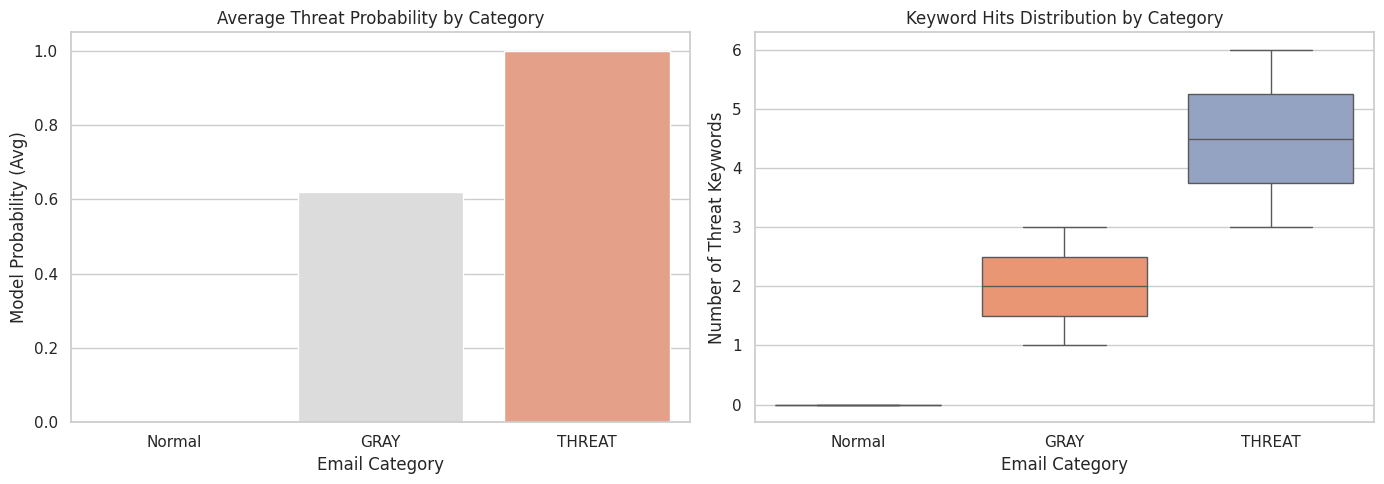

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_plot = scored.copy()
df_plot['True Category'] = [lbl.split(' — ')[0] for lbl in labels]

sns.barplot(
    data=df_plot, 
    x='True Category', 
    y='threat_proba', 
    ax=axes[0], 
    palette='coolwarm', 
    hue='True Category',
    legend=False,
    errorbar=None
)
axes[0].set_title('Average Threat Probability by Category')
axes[0].set_xlabel('Email Category')
axes[0].set_ylabel('Model Probability (Avg)')
axes[0].set_ylim(0, 1.05)

feat_df_plot = engineer_features(df_cases, internal_domain=CFG['internal_domain'])
feat_df_plot['True Category'] = [lbl.split(' — ')[0] for lbl in labels]

sns.boxplot(
    data=feat_df_plot, 
    x='True Category', 
    y='keyword_hits', 
    ax=axes[1], 
    palette='Set2',
    hue='True Category',
    legend=False
)
axes[1].set_title('Keyword Hits Distribution by Category')
axes[1].set_xlabel('Email Category')
axes[1].set_ylabel('Number of Threat Keywords')

plt.tight_layout()
plt.show()

In [47]:
import joblib

joblib.dump(voters, 'model.pkl', compress=3)
joblib.dump(scaler, 'scaler.pkl', compress=3)
joblib.dump(tfidf, 'tfidf.pkl', compress=3)

print("✓ تم حفظ الموديل والـ Scaler والـ TF-IDF بنجاح بصيغة .pkl")

✓ تم حفظ الموديل والـ Scaler والـ TF-IDF بنجاح بصيغة .pkl
